In [176]:
#analysis -> feature engineering -> model -> web app

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [178]:
pd.set_option("display.max_columns", None)

In [179]:
sns.set_style("whitegrid")

In [180]:
df=pd.read_csv("../data/german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [181]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [182]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [183]:
df.shape

(1000, 11)

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [185]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [186]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [187]:
df["Job"].unique()

array([2, 1, 3, 0])

In [188]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [189]:
df.duplicated().sum()

np.int64(0)

In [190]:
df.dropna(inplace=True)
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
7,7,35,male,3,rent,little,moderate,6948,36,car,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad


In [191]:
df.columns


Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [192]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [193]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

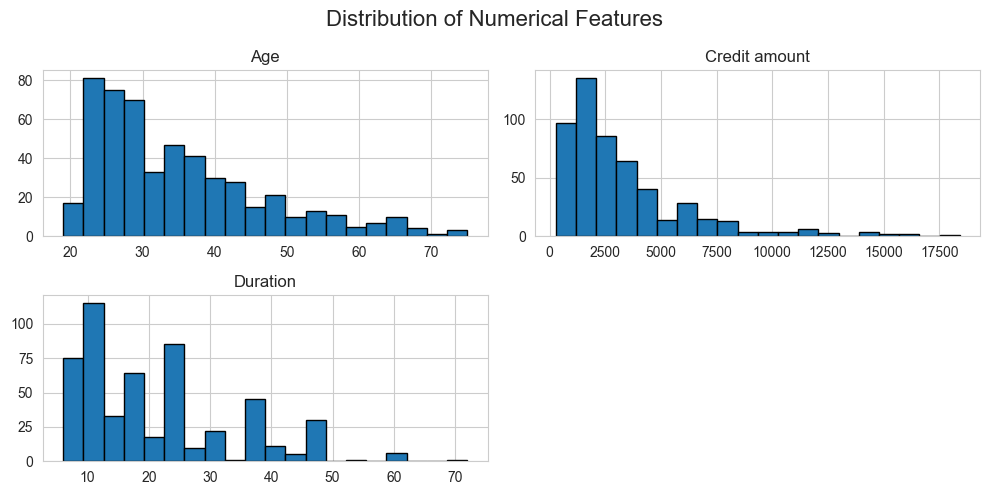

In [194]:
df[["Age","Credit amount","Duration"]].hist(bins=20, edgecolor="black", figsize=(10,5))
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()

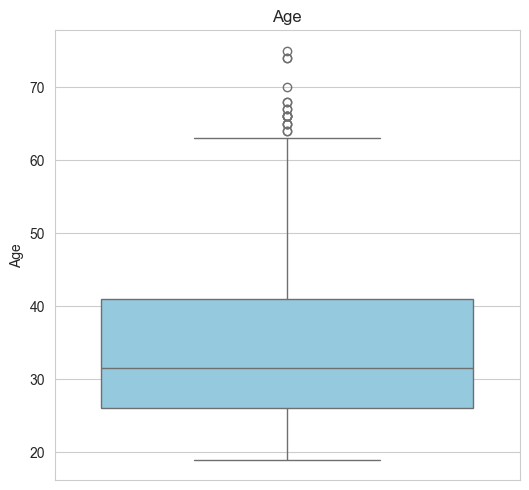

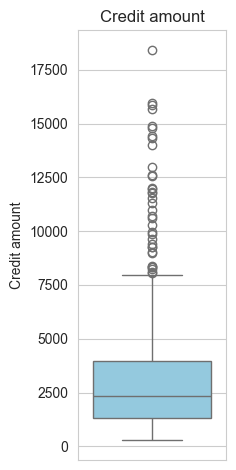

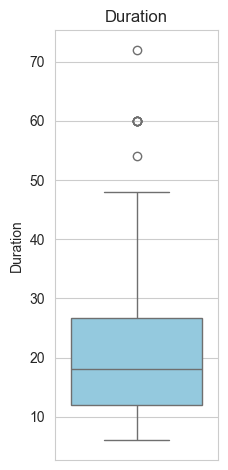

In [195]:
plt.figure(figsize=( 15,5))
for i , col in enumerate (["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

    plt.tight_layout()  
    plt.show()

In [196]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
332,24,female,3,own,moderate,moderate,7408,60,car,bad
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
714,27,male,3,own,little,moderate,14027,60,car,bad
938,42,male,2,free,little,moderate,6288,60,education,bad
973,36,male,2,rent,little,little,7297,60,business,bad


In [197]:
categorical_cols=["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

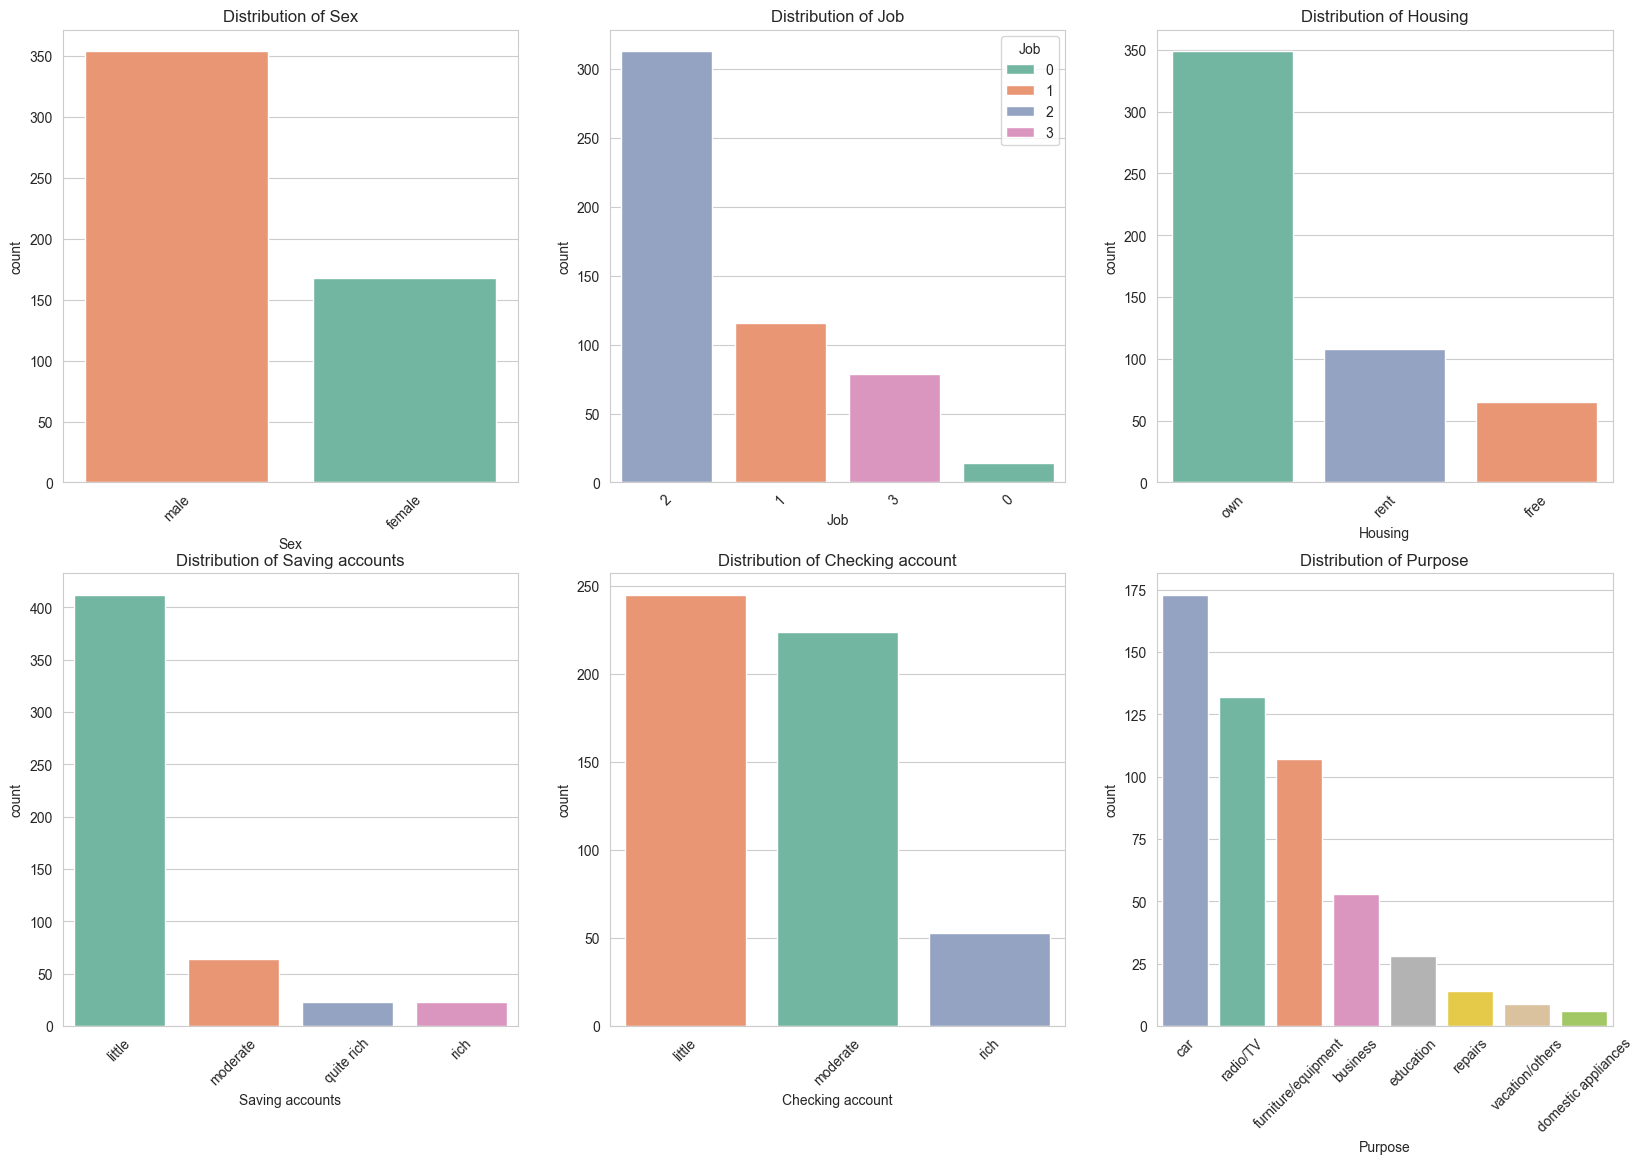

In [198]:
plt.figure(figsize=(20,20))
for i, col in enumerate(categorical_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(data=df, x=col,hue=col, palette="Set2", order=df[col].value_counts().index)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation=45)

In [199]:
corr = df[["Age","Job", "Credit amount","Duration"]].corr()

In [200]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


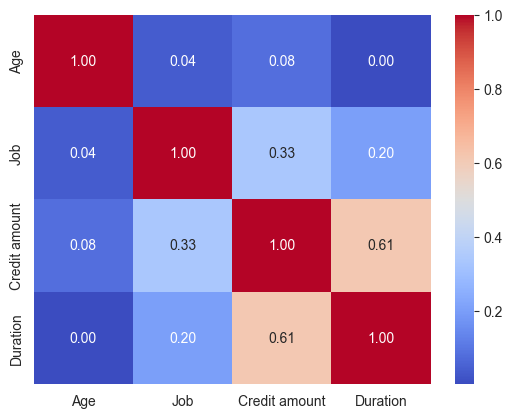

In [201]:
sns.heatmap(corr, annot=True, cmap="coolwarm",fmt=".2f")
plt.show()

In [202]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [203]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [204]:
pd.pivot_table(df, values="Credit amount",index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


Text(0.5, 1.0, 'Credit Amount vs Age colored by sex and sized by Duration')

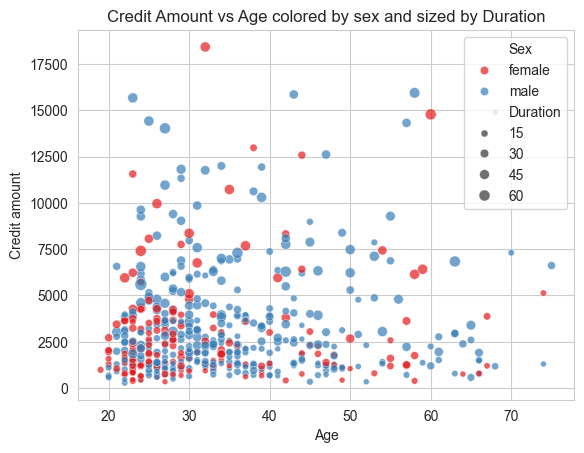

In [205]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex",size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit Amount vs Age colored by sex and sized by Duration")

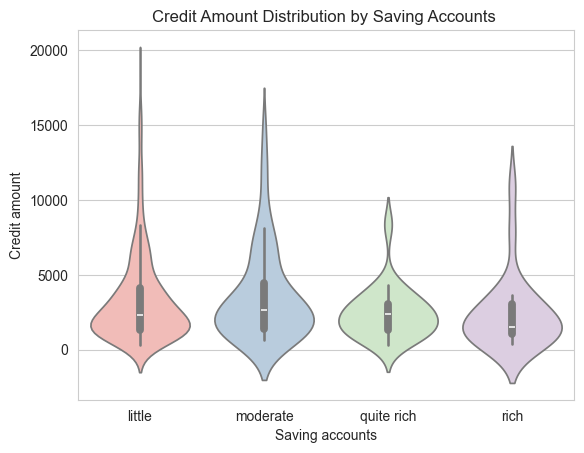

In [206]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount" , hue="Saving accounts" ,palette="Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts ")
plt.show()

In [207]:
df["Risk"].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

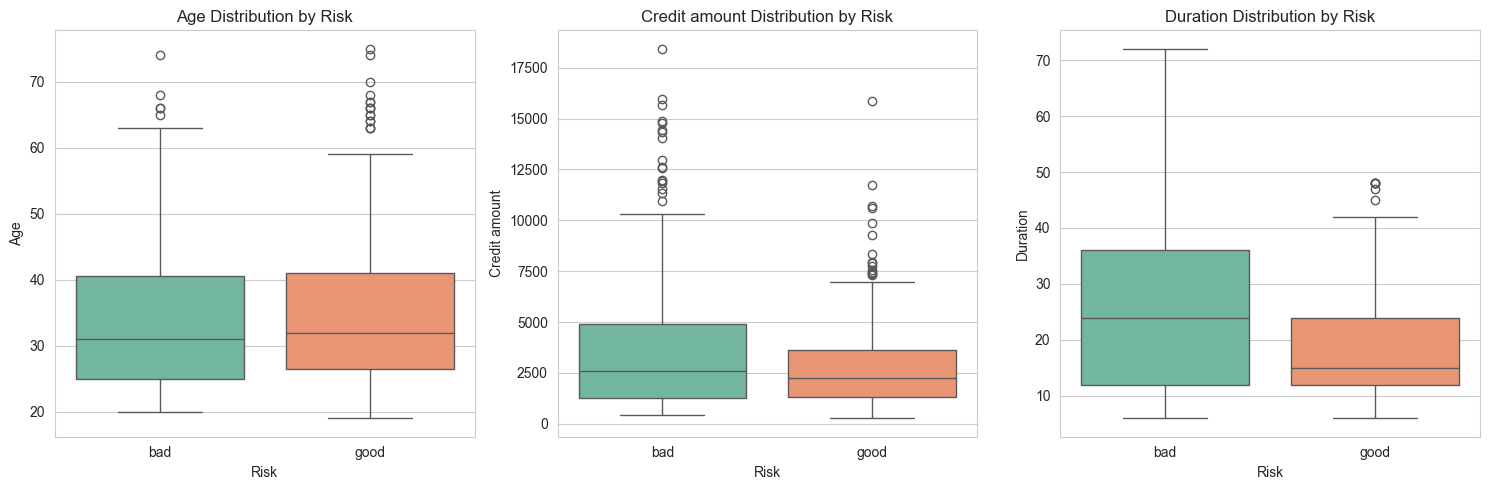

In [208]:
plt.figure(figsize=(15,5))
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x="Risk", y=df[col], hue="Risk", palette="Set2")
    plt.title(f"{col} Distribution by Risk")
    plt.tight_layout()

In [209]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

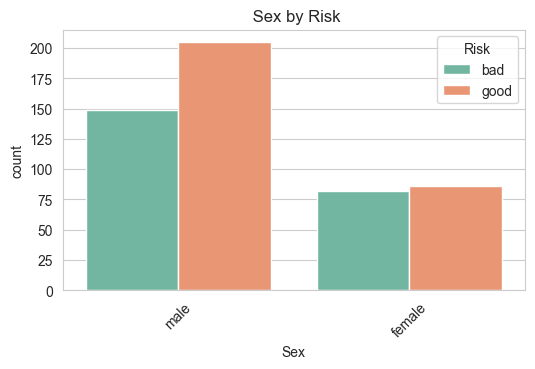

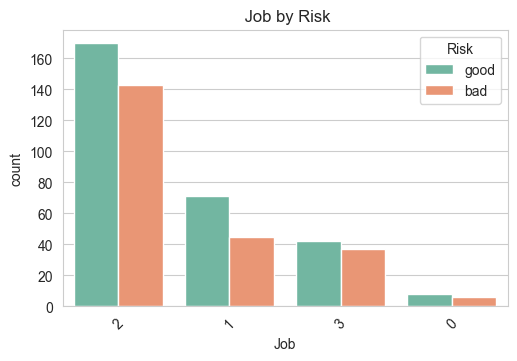

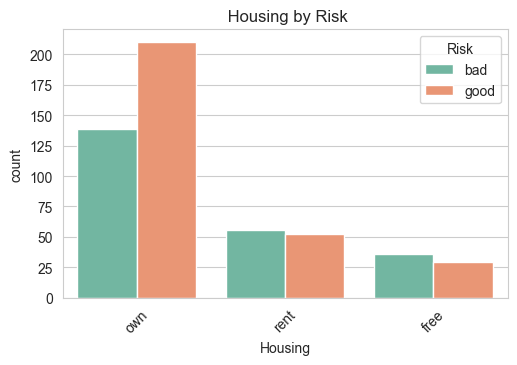

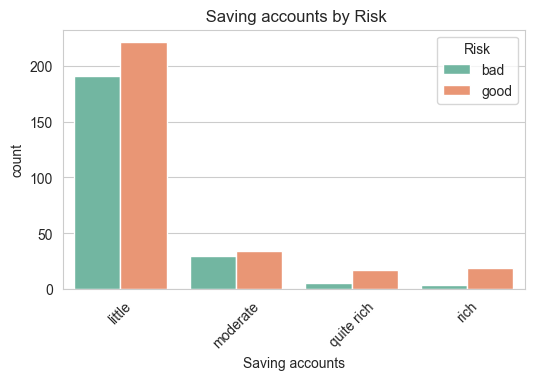

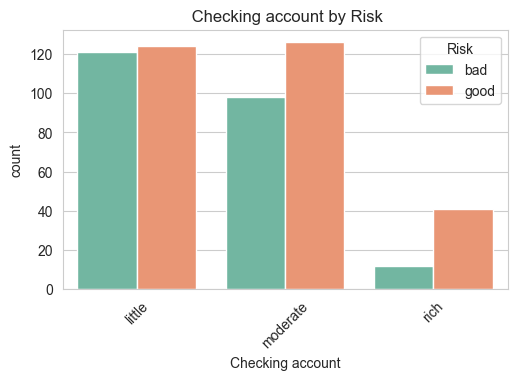

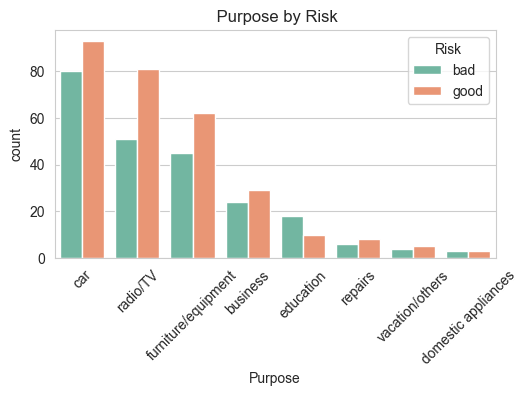

In [210]:

for i, col in enumerate(categorical_cols):
    plt.figure(figsize=(15,10))
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col,hue="Risk", palette="Set2", order=df[col].value_counts().index)
    plt.title(f" {col} by Risk")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


In [211]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [212]:
features=["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]

In [213]:
target="Risk"

In [214]:
df_model=df[features + [target]].copy()



In [215]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
1,22,female,2,own,little,moderate,5951,48,bad
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad
7,35,male,3,rent,little,moderate,6948,36,good
9,28,male,3,own,little,moderate,5234,30,bad


In [216]:

from sklearn.preprocessing import LabelEncoder
import joblib

In [217]:
cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")

In [218]:
le_dict={}

In [219]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [220]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le, f"{col}_encoder.pkl")

In [221]:
le_target=LabelEncoder()

In [222]:
target

'Risk'

In [223]:
df_model[target]=le_target.fit_transform(df_model[target])

In [224]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [225]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [226]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
1,22,0,2,1,0,1,5951,48,0
3,45,1,2,0,0,0,7882,42,1
4,53,1,2,0,0,0,4870,24,0
7,35,1,3,2,0,1,6948,36,1
9,28,1,3,1,0,1,5234,30,0
